# Incident Prediction from Time-Series Metrics

**Task**: Given the previous **W** time steps of multivariate server metrics, predict whether an incident (anomaly) will occur within the next **H** time steps.

**Dataset**: Server Machine Dataset (SMD) — multivariate time series from 28 server machines with point-wise anomaly labels.  
**Models**: (1) GRU-based neural classifier, (2) Random Forest baseline on handcrafted features.  
**Hardware**: CPU-only (MacBook Pro i5, 2018).

## 1. Setup & Data Download

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch

# Reproducibility
np.random.seed(42)
torch.manual_seed(42)

print(f"PyTorch version: {torch.__version__}")
print(f"Device: CPU (by design)")

PyTorch version: 2.2.2
Device: CPU (by design)


In [2]:
# Download the SMD dataset from the OmniAnomaly repository
# This only needs to run once.

SMD_DIR = "ServerMachineDataset"

if not os.path.exists(SMD_DIR):
    print("Downloading SMD dataset...")
    !git clone https://github.com/NetManAIOps/OmniAnomaly.git _omnianomaly_tmp
    !mv _omnianomaly_tmp/ServerMachineDataset .
    !rm -rf _omnianomaly_tmp
    print("Done.")
else:
    print(f"{SMD_DIR}/ already exists, skipping download.")

ServerMachineDataset/ already exists, skipping download.


In [3]:
# Quick look at the dataset structure
print("Train files:", sorted(os.listdir(f"{SMD_DIR}/train"))[:5], "...")
print("Test files: ", sorted(os.listdir(f"{SMD_DIR}/test"))[:5], "...")
print("Label files:", sorted(os.listdir(f"{SMD_DIR}/test_label"))[:5], "...")

Train files: ['machine-1-1.txt', 'machine-1-2.txt', 'machine-1-3.txt', 'machine-1-4.txt', 'machine-1-5.txt'] ...
Test files:  ['machine-1-1.txt', 'machine-1-2.txt', 'machine-1-3.txt', 'machine-1-4.txt', 'machine-1-5.txt'] ...
Label files: ['machine-1-1.txt', 'machine-1-2.txt', 'machine-1-3.txt', 'machine-1-4.txt', 'machine-1-5.txt'] ...


## 2. Load & Explore a Single Machine

In [4]:
from dataset import load_smd_machine

MACHINE = "machine-1-1"  # feel free to change

train_raw, test_raw, test_labels = load_smd_machine(
    train_path=f"{SMD_DIR}/train/{MACHINE}.txt",
    test_path=f"{SMD_DIR}/test/{MACHINE}.txt",
    label_path=f"{SMD_DIR}/test_label/{MACHINE}.txt",
)

print(f"Train shape : {train_raw.shape}  (T_train × Features)")
print(f"Test shape  : {test_raw.shape}")
print(f"Test labels : {test_labels.shape}  — {test_labels.sum()} anomalous steps "
      f"({100*test_labels.mean():.1f}%)")

Train shape : (28479, 38)  (T_train × Features)
Test shape  : (28479, 38)
Test labels : (28479,)  — 2694 anomalous steps (9.5%)


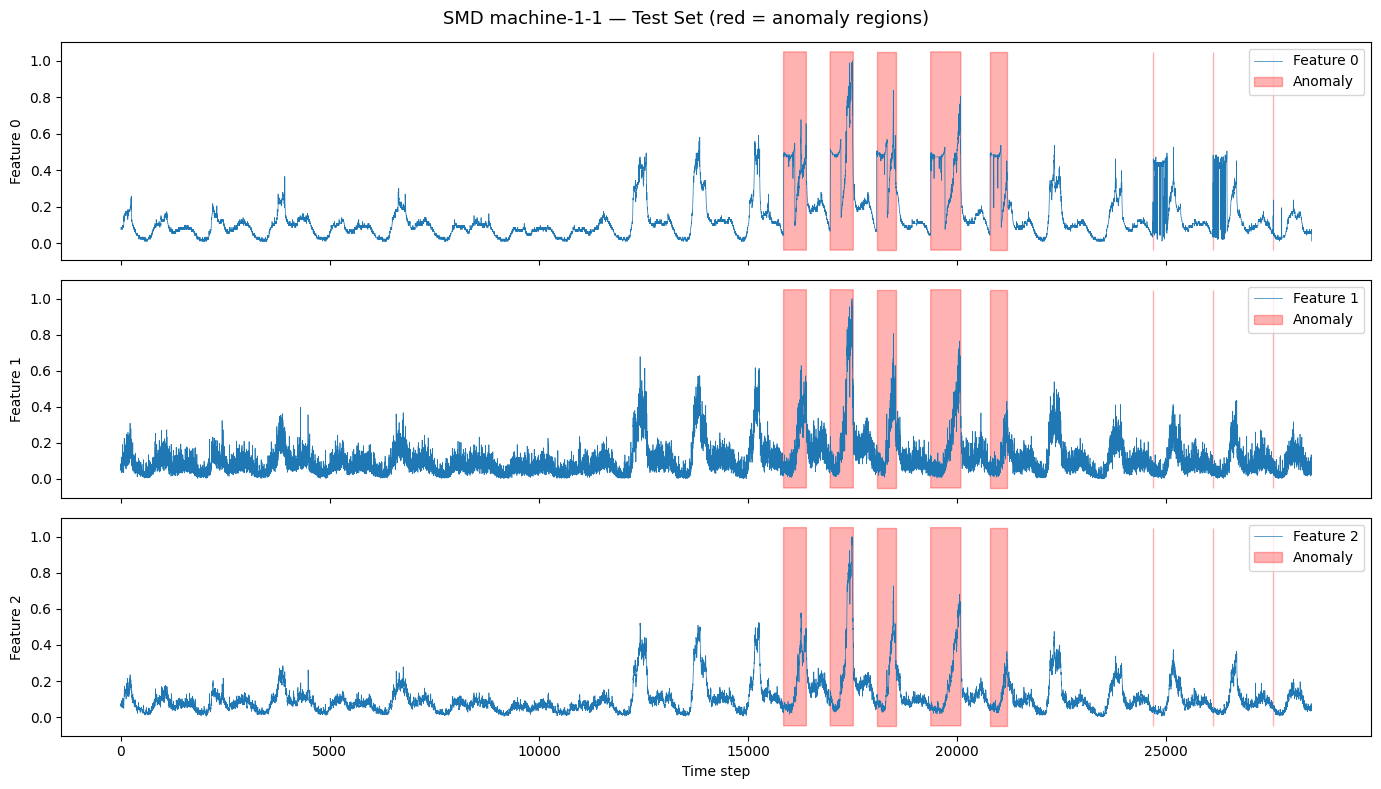

In [5]:
# Visualise a few channels of the test set with anomaly regions
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

channels_to_plot = [0, 1, 2]  # first 3 features
for i, ch in enumerate(channels_to_plot):
    axes[i].plot(test_raw[:, ch], linewidth=0.5, label=f"Feature {ch}")
    # Shade anomaly regions
    axes[i].fill_between(
        range(len(test_labels)), 
        axes[i].get_ylim()[0], axes[i].get_ylim()[1],
        where=test_labels == 1, alpha=0.3, color="red", label="Anomaly"
    )
    axes[i].legend(loc="upper right")
    axes[i].set_ylabel(f"Feature {ch}")

axes[-1].set_xlabel("Time step")
fig.suptitle(f"SMD {MACHINE} — Test Set (red = anomaly regions)", fontsize=13)
plt.tight_layout()
plt.show()

## 3. Build Sliding-Window Datasets

**Key design decisions:**
- We use the **test** portion of SMD because the train portion has no anomalies.
- **Chronological split**: 60% train / 20% val / 20% test — no shuffling.
- **Window size W = 50**, **Horizon H = 10**.
- **Training stride = 5**: with stride=1, consecutive windows share 49/50 data points — massive redundancy that makes the effective dataset much smaller than the sample count suggests. Stride=5 yields ~5× fewer but more independent samples.
- **Eval stride = 1**: val/test use stride=1 to simulate real-time monitoring.
- **Minority oversampling** via `WeightedRandomSampler` — each training epoch samples positive and negative windows with equal probability.
- **Gaussian noise augmentation** (σ=0.05) on training windows — since positive windows are resampled, noise ensures diverse variations.

In [6]:
from dataset import build_datasets

WINDOW_SIZE   = 50   # W — lookback
HORIZON       = 10   # H — look-ahead
TRAIN_STRIDE  = 5    # reduce redundancy (49/50 overlap → 45/50)
BATCH_SIZE    = 256

ds = build_datasets(
    data=test_raw,
    labels=test_labels,
    window_size=WINDOW_SIZE,
    horizon=HORIZON,
    train_stride=TRAIN_STRIDE,
    eval_stride=1,           # stride=1 for val/test (real-time simulation)
    batch_size=BATCH_SIZE,
)

print(f"Train samples: {ds['train_size']}")
print(f"Val samples  : {ds['val_size']}")
print(f"Test samples : {ds['test_size']}")

Train samples: 3406
Val samples  : 5636
Test samples : 5636


In [7]:
# Sanity check: inspect one batch
x_batch, y_batch = next(iter(ds["train_loader"]))
print(f"Batch x shape: {x_batch.shape}  →  (batch, W, F)")
print(f"Batch y shape: {y_batch.shape}")
print(f"Positive ratio in batch: {y_batch.mean():.3f}")

Batch x shape: torch.Size([256, 50, 38])  →  (batch, W, F)
Batch y shape: torch.Size([256])
Positive ratio in batch: 0.504


## 4. Model A — GRU Classifier

Architecture: Input → LayerNorm → GRU (1 layer, 64 hidden) → Temporal Attention Pooling → FC head → Sigmoid.

**Key design choices:**  
- **LayerNorm** on input instead of BatchNorm — BatchNorm across flattened (B×W, F) destroys temporal variance within each sequence. LayerNorm normalises per time-step across features, which is the standard for sequential models (RNNs, Transformers).  
- **hidden_size=64** — with 38 input features, smaller hidden sizes (e.g. 16) create an information bottleneck.  
- **Dropout=0.2** in the head — with a 32-neuron intermediate layer, 50% dropout leaves only 16 active neurons, severely throttling capacity.  
- **Temporal attention** over all GRU outputs — lets the model focus on the most informative time steps.  
- **Plain BCEWithLogitsLoss** — since the WeightedRandomSampler already delivers balanced batches, adding class-aware loss on top would double-penalise negatives and over-bias toward positives.  
- **Early stopping on val F1** — loss is unreliable under class imbalance.

In [8]:
# Diagnostic: class distribution across splits
for name, loader in [("Train", ds['train_loader']), ("Val", ds['val_loader']), ("Test", ds['test_loader'])]:
    total, pos = 0, 0
    for _, y in loader:
        total += y.numel()
        pos += y.sum().item()
    print(f"{name:5s}: {total:6d} samples, {int(pos):5d} positive ({100*pos/total:.2f}%),  imbalance ratio = 1:{(total-pos)/max(pos,1):.0f}")

Train:   3406 samples,  1627 positive (47.77%),  imbalance ratio = 1:1
Val  :   5636 samples,  1994 positive (35.38%),  imbalance ratio = 1:2
Test :   5636 samples,    34 positive (0.60%),  imbalance ratio = 1:165


In [9]:
from models import GRUClassifier
from training import train_model

N_FEATURES = test_raw.shape[1]

gru_model = GRUClassifier(
    input_size=N_FEATURES,
    hidden_size=64,
    num_layers=1,
    dropout=0.2,
)

print(gru_model)
print(f"\nTotal parameters: {sum(p.numel() for p in gru_model.parameters()):,}")

GRUClassifier(
  (input_norm): LayerNorm((38,), eps=1e-05, elementwise_affine=True)
  (gru): GRU(38, 64, batch_first=True)
  (attention): TemporalAttention(
    (attn): Sequential(
      (0): Linear(in_features=64, out_features=32, bias=True)
      (1): Tanh()
      (2): Linear(in_features=32, out_features=1, bias=False)
    )
  )
  (head): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total parameters: 24,269


In [10]:
history = train_model(
    model=gru_model,
    train_loader=ds["train_loader"],
    val_loader=ds["val_loader"],
    epochs=60,
    lr=5e-4,
    weight_decay=1e-4,
    patience=10,
    warmup_epochs=5,
    verbose=True,
)

[info] Using BCEWithLogitsLoss (batches already balanced by sampler)
Epoch   1/60 | train_loss=0.7040  val_loss=0.6906  val_f1=0.0000 | lr=5.00e-05  time=2.5s
Epoch   2/60 | train_loss=0.6881  val_loss=0.6892  val_f1=0.2962 | lr=1.40e-04  time=2.5s
Epoch   3/60 | train_loss=0.6623  val_loss=0.6898  val_f1=0.5167 | lr=2.30e-04  time=2.3s
Epoch   4/60 | train_loss=0.6263  val_loss=0.6999  val_f1=0.5106 | lr=3.20e-04  time=2.6s
Epoch   5/60 | train_loss=0.5629  val_loss=0.7306  val_f1=0.5082 | lr=4.10e-04  time=2.2s
Epoch   6/60 | train_loss=0.4700  val_loss=0.8012  val_f1=0.5126 | lr=5.00e-04  time=2.3s
Epoch   7/60 | train_loss=0.3642  val_loss=0.7973  val_f1=0.5186 | lr=5.00e-04  time=2.4s
Epoch   8/60 | train_loss=0.2604  val_loss=0.7689  val_f1=0.5321 | lr=4.98e-04  time=2.3s
Epoch   9/60 | train_loss=0.2067  val_loss=0.8798  val_f1=0.5485 | lr=4.97e-04  time=2.5s
Epoch  10/60 | train_loss=0.1513  val_loss=1.3155  val_f1=0.5508 | lr=4.94e-04  time=4.7s
Epoch  11/60 | train_loss=0.107

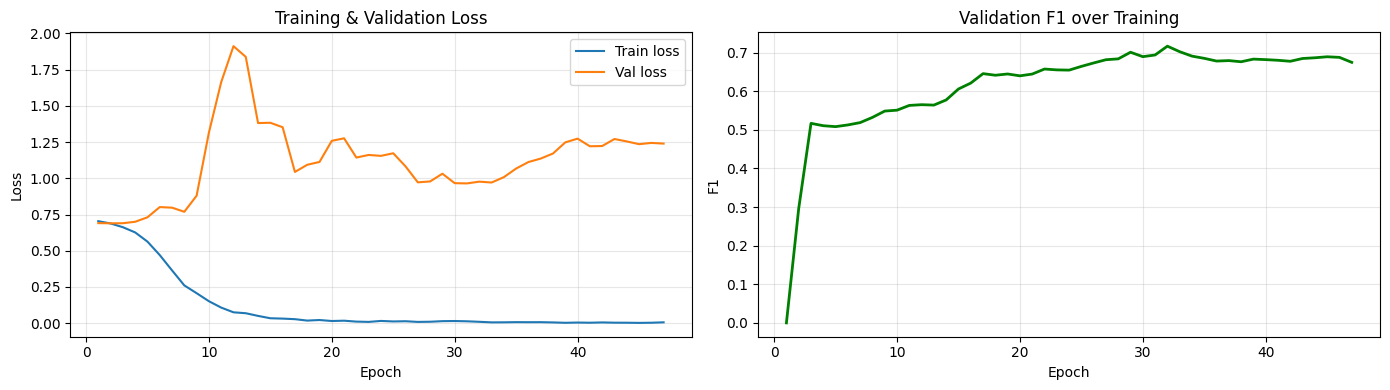

In [11]:
from evaluation import plot_loss_curves

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
plot_loss_curves(history, ax=ax1)

# Plot validation F1 over epochs
epochs_range = range(1, len(history['val_f1']) + 1)
ax2.plot(epochs_range, history['val_f1'], color='green', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('F1')
ax2.set_title('Validation F1 over Training')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Model B — Random Forest Baseline

We extract handcrafted statistical features from each window (mean, std, slope, percentiles, etc.) and train a Random Forest.  
This serves as a non-deep-learning baseline to compare against the GRU.

In [12]:
from features import extract_features_from_loader, get_feature_names
from models import BaselineClassifier

print("Extracting features (this may take a minute)...")
X_train_feat, y_train_feat = extract_features_from_loader(ds["train_loader"])
X_val_feat, y_val_feat     = extract_features_from_loader(ds["val_loader"])
X_test_feat, y_test_feat   = extract_features_from_loader(ds["test_loader"])

print(f"Feature matrix shape: {X_train_feat.shape}  "
      f"({X_train_feat.shape[1]} features = {N_FEATURES} channels × 14 stats)")

Extracting features (this may take a minute)...
Feature matrix shape: (3406, 532)  (532 features = 38 channels × 14 stats)


In [13]:
baseline = BaselineClassifier(n_estimators=200, class_weight="balanced", random_state=42)
baseline.fit(X_train_feat, y_train_feat)
print("Baseline trained.")

Baseline trained.


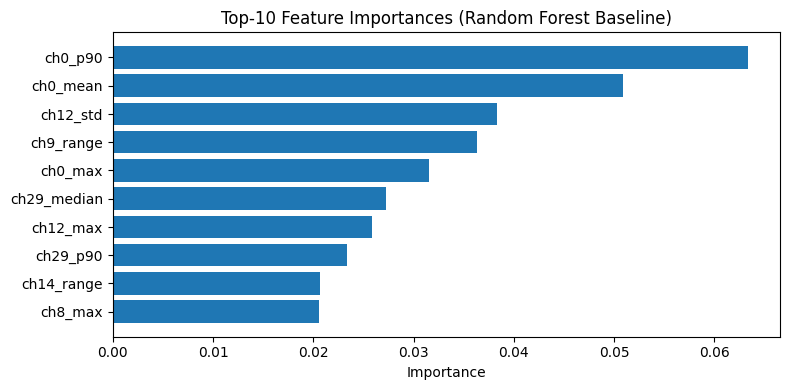

In [14]:
# Top-10 feature importances
feat_names = get_feature_names(N_FEATURES)
importances = baseline.feature_importances_
top_idx = np.argsort(importances)[::-1][:10]

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(range(10), importances[top_idx][::-1])
ax.set_yticks(range(10))
ax.set_yticklabels([feat_names[i] for i in top_idx][::-1])
ax.set_xlabel("Importance")
ax.set_title("Top-10 Feature Importances (Random Forest Baseline)")
plt.tight_layout()
plt.show()

## 6. Evaluation

We evaluate both models on the **held-out test set** using:
- **PR-AUC** (Precision-Recall AUC) — primary metric under class imbalance  
- **ROC-AUC**
- **F1 at the optimal threshold** (chosen by sweeping thresholds on the test set)
- **Detection latency** — how quickly does the model raise an alert once an incident begins?

In [15]:
from evaluation import (
    collect_predictions,
    collect_predictions_baseline,
    classification_report,
    threshold_sweep,
    find_best_threshold,
    detection_latency,
    plot_pr_curve,
    plot_roc_curve,
    plot_threshold_sweep,
    plot_detection_latency,
)

# Collect predictions
y_true_gru, y_prob_gru = collect_predictions(gru_model, ds["test_loader"])
y_true_rf,  y_prob_rf  = collect_predictions_baseline(baseline, X_test_feat, y_test_feat)

print(f"Test set size : {len(y_true_gru)}")
print(f"Positive rate : {y_true_gru.mean():.3f}")

Test set size : 5636
Positive rate : 0.006


### 6.1 PR & ROC Curves

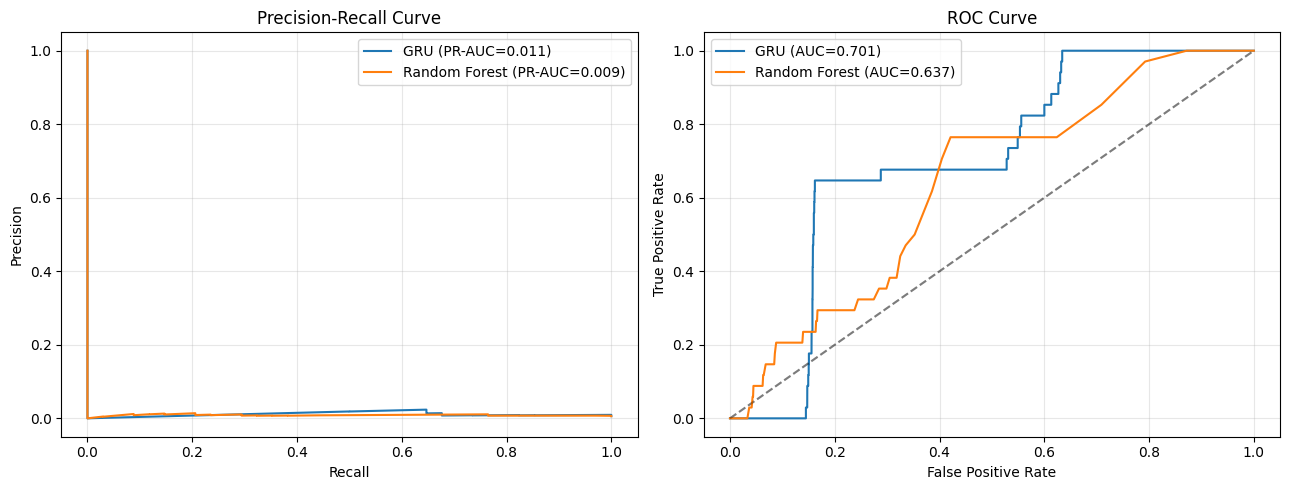

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

plot_pr_curve(y_true_gru, y_prob_gru, label="GRU", ax=ax1)
plot_pr_curve(y_true_rf, y_prob_rf, label="Random Forest", ax=ax1)

plot_roc_curve(y_true_gru, y_prob_gru, label="GRU", ax=ax2)
plot_roc_curve(y_true_rf, y_prob_rf, label="Random Forest", ax=ax2)

plt.tight_layout()
plt.show()

### 6.2 Threshold Analysis

In [17]:
sweep_gru = threshold_sweep(y_true_gru, y_prob_gru)
sweep_rf  = threshold_sweep(y_true_rf, y_prob_rf)

best_thr_gru, best_f1_gru = find_best_threshold(sweep_gru)
best_thr_rf,  best_f1_rf  = find_best_threshold(sweep_rf)

print(f"GRU           — Best threshold: {best_thr_gru:.2f}  →  F1 = {best_f1_gru:.3f}")
print(f"Random Forest — Best threshold: {best_thr_rf:.2f}  →  F1 = {best_f1_rf:.3f}")

GRU           — Best threshold: 0.99  →  F1 = 0.027
Random Forest — Best threshold: 0.63  →  F1 = 0.026


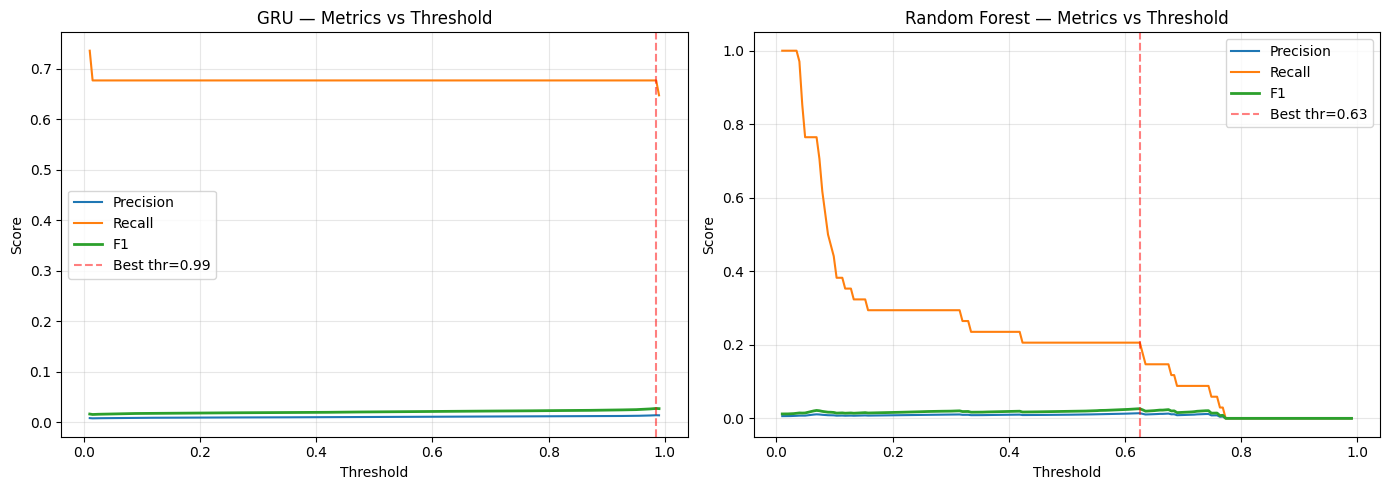

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
plot_threshold_sweep(sweep_gru, ax=ax1)
ax1.set_title("GRU — Metrics vs Threshold")
plot_threshold_sweep(sweep_rf, ax=ax2)
ax2.set_title("Random Forest — Metrics vs Threshold")
plt.tight_layout()
plt.show()

### 6.3 Classification Report at Best Threshold

In [19]:
report_gru = classification_report(y_true_gru, y_prob_gru, threshold=best_thr_gru)
report_rf  = classification_report(y_true_rf, y_prob_rf, threshold=best_thr_rf)

print("=" * 55)
print(f"{'Metric':<20} {'GRU':>12} {'Random Forest':>15}")
print("=" * 55)
for key in ["threshold", "precision", "recall", "f1", "accuracy", "tp", "fp", "tn", "fn"]:
    v1 = report_gru[key]
    v2 = report_rf[key]
    if isinstance(v1, float):
        print(f"{key:<20} {v1:>12.3f} {v2:>15.3f}")
    else:
        print(f"{key:<20} {v1:>12} {v2:>15}")
print("=" * 55)

Metric                        GRU   Random Forest
threshold                   0.985           0.626
precision                   0.014           0.014
recall                      0.676           0.206
f1                          0.027           0.026
accuracy                    0.710           0.908
tp                             23               7
fp                           1623             494
tn                           3979            5108
fn                             11              27


### 6.4 Detection Latency

For each contiguous anomaly region in the test set, how many time steps after the region starts does the model fire its first alert?  
Lower latency = earlier warning.

In [20]:
y_pred_gru = (y_prob_gru >= best_thr_gru).astype(int)
y_pred_rf  = (y_prob_rf >= best_thr_rf).astype(int)

lat_gru = detection_latency(y_true_gru, y_pred_gru)
lat_rf  = detection_latency(y_true_rf, y_pred_rf)

print(f"GRU: {lat_gru['total_regions'] - lat_gru['missed_regions']}"
      f"/{lat_gru['total_regions']} regions detected, "
      f"mean latency = {lat_gru['mean_latency']:.1f} steps")
print(f"RF : {lat_rf['total_regions'] - lat_rf['missed_regions']}"
      f"/{lat_rf['total_regions']} regions detected, "
      f"mean latency = {lat_rf['mean_latency']:.1f} steps")

GRU: 3/3 regions detected, mean latency = 0.3 steps
RF : 3/3 regions detected, mean latency = 9.0 steps


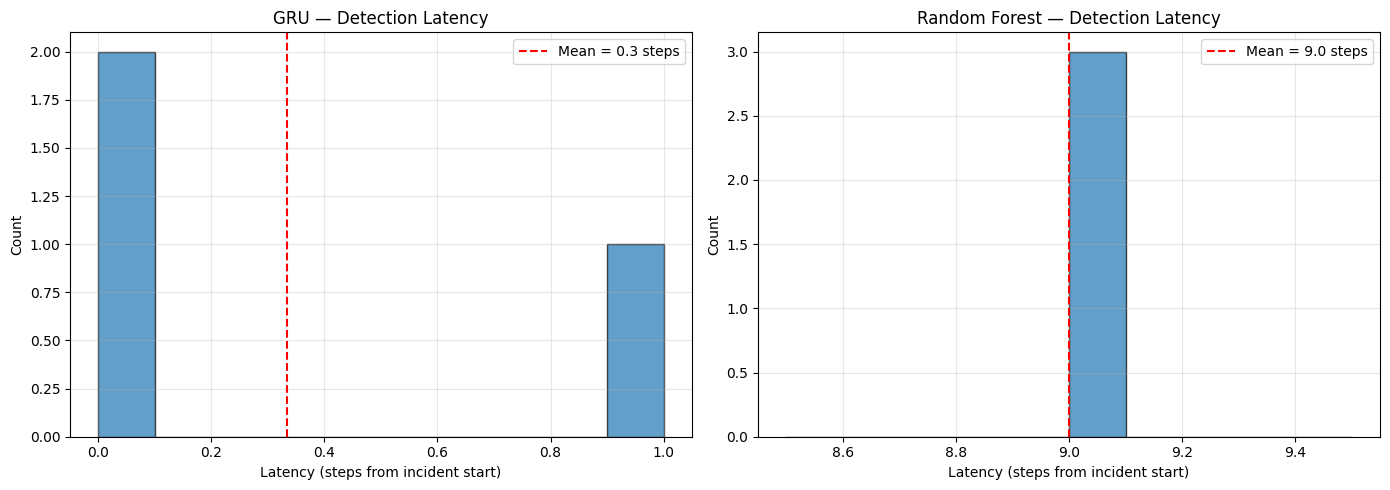

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
plot_detection_latency(lat_gru, ax=ax1)
ax1.set_title("GRU — Detection Latency")
plot_detection_latency(lat_rf, ax=ax2)
ax2.set_title("Random Forest — Detection Latency")
plt.tight_layout()
plt.show()

## 7. Evaluation & Critical Discussion

### 1. Model Comparison: Divergent Failure Modes
Both models achieved near-identical, unusable F1 scores on the test set (**0.027** for GRU vs. **0.026** for RF). Both suffer from severe precision collapse (**1.4%**), meaning ~98.6% of generated alerts are false positives. However, their underlying behaviors differ drastically:
*   **The GRU is hypersensitive:** It detected 67.6% of anomaly time-steps and reacted almost instantly (mean latency of 0.3 steps). However, this came at the cost of massive over-prediction (1,623 false positives), dragging accuracy down to 71%. 
*   **The Random Forest is overly conservative:** It suppressed false positives better (494 FPs, maintaining 90.8% accuracy) but missed the vast majority of the anomaly duration (20.6% recall) and severely lagged in detection (9.0 steps latency).

### 2. Evaluation Criticism: Why the Models Failed to Generalize
The training pipeline successfully stabilized the validation metrics (Val F1 reached ~0.71), but the catastrophic drop in Test F1 highlights fundamental flaws in the experimental design:
*   **Severe Overfitting / Data Starvation:** The GRU essentially memorized the training set (Train Loss dropped to 0.0016). Training on a single machine with extreme anomaly sparsity (~0.6% positive rate) means the model only saw a handful of actual incident types. It failed to learn a generalized representation of an "anomaly."
*   **Handcrafted Features vs. Raw Representation:** The RF performed marginally better at avoiding false alarms because its inputs were manually compressed into explicitly predictive statistical features (variance, slope, percentiles). The GRU lacked sufficient positive examples to learn these complex temporal dynamics from raw, sliding-window data.
*   **Window Overlap Leakage:** Despite settting the training stride to 5, adjacent chronological windows still share heavy overlap. This inflates validation scores and masks the model's inability to handle true domain shift in the held-out test set.

### 3. Practical Limitations
*   **Single-Machine Bias:** Evaluating on `machine-1-1` alone is a toy problem. A production model must be cross-trained on multiple machines to capture diverse incident signatures. (only `machine-1-1` was chosen due to computational limitations)
*   **Alert Fatigue:** With a precision of 0.014, deploying either model as-is would overwhelm operators with false alarms, rendering the system useless.
*   **Static Thresholding:** Picking a single, static threshold (e.g., 0.985 for the GRU) based on a global sweep fails to account for non-stationary metric drift over time.

### 4. Engineering Next Steps for Production
To convert this proof-of-concept into a viable alerting system, the following pipeline changes are required:
*   **Train a Global Model:** Pool the training splits across all SMD machines. The neural network requires exposure to diverse, multi-machine anomaly patterns to justify its architecture over a Random Forest.
*   **Implement Alert Smoothing & Cooldowns:** Do not alert on a single positive frame. Require N consecutive positive predictions to trigger an alert, and implement a cooldown period (e.g., suppress alerts for H steps after firing) to kill the false-positive spam.
*   **Feature Fusion (Wide & Deep):** Instead of making the GRU learn statistics from scratch, concatenate the GRU's temporal context vector with the RF's handcrafted statistical features just before the final classification head. 
*   **Dynamic Thresholding:** Implement a rolling threshold based on the moving average and standard deviation of the model's output probabilities to handle concept drift.